In [139]:
import numpy as np
import pandas as pd
import matplotlib as mpl
import matplotlib.pyplot as plt
from statsmodels.datasets import get_rdataset
from sklearn.decomposition import PCA
from sklearn.metrics import pairwise_distances
from sklearn.preprocessing import StandardScaler
from ISLP import load_data
from sklearn.cluster import (KMeans, AgglomerativeClustering)
from scipy.cluster.hierarchy import (linkage,dendrogram, cut_tree)
from ISLP.cluster import compute_linkage
import os
os.getcwd()

'/home/brett/Documents/PhD/DDS-8555 Predictive Analysis/Week 7'

In [140]:
USArrests=get_rdataset('USArrests').data
USArrests.index

Index(['Alabama', 'Alaska', 'Arizona', 'Arkansas', 'California', 'Colorado',
       'Connecticut', 'Delaware', 'Florida', 'Georgia', 'Hawaii', 'Idaho',
       'Illinois', 'Indiana', 'Iowa', 'Kansas', 'Kentucky', 'Louisiana',
       'Maine', 'Maryland', 'Massachusetts', 'Michigan', 'Minnesota',
       'Mississippi', 'Missouri', 'Montana', 'Nebraska', 'Nevada',
       'New Hampshire', 'New Jersey', 'New Mexico', 'New York',
       'North Carolina', 'North Dakota', 'Ohio', 'Oklahoma', 'Oregon',
       'Pennsylvania', 'Rhode Island', 'South Carolina', 'South Dakota',
       'Tennessee', 'Texas', 'Utah', 'Vermont', 'Virginia', 'Washington',
       'West Virginia', 'Wisconsin', 'Wyoming'],
      dtype='object', name='rownames')

In [141]:
USArrests.index.name = 'State'
USArrests.head()

,Murder,Assault,UrbanPop,Rape
State,,,,
Alabama,13.2,236,58,21.2
Alaska,10.0,263,48,44.5
Arizona,8.1,294,80,31.0
Arkansas,8.8,190,50,19.5
California,9.0,276,91,40.6


In [142]:
USArrests.columns

Index(['Murder', 'Assault', 'UrbanPop', 'Rape'], dtype='object')

In [143]:
USArrests.describe()

,Murder,Assault,UrbanPop,Rape
count,50.00000,50.000000,50.000000,50.000000
mean,7.78800,170.760000,65.540000,21.232000
std,4.35551,83.337661,14.474763,9.366385
min,0.80000,45.000000,32.000000,7.300000
25%,4.07500,109.000000,54.500000,15.075000
50%,7.25000,159.000000,66.000000,20.100000
75%,11.25000,249.000000,77.750000,26.175000
max,17.40000,337.000000,91.000000,46.000000


# Applied question 9

### Part a.

In [144]:
scaler = StandardScaler(with_std = True, with_mean = True)
USArrestsScaled = scaler.fit_transform(USArrests)
cluster = AgglomerativeClustering
HClust = cluster(distance_threshold = 0, n_clusters = None, linkage='complete')
HClust.fit(USArrests)

,n_clusters,None
,metric,'euclidean'
,memory,None
,connectivity,None
,compute_full_tree,'auto'
,linkage,'complete'
,distance_threshold,0
,compute_distances,False


### Part b.

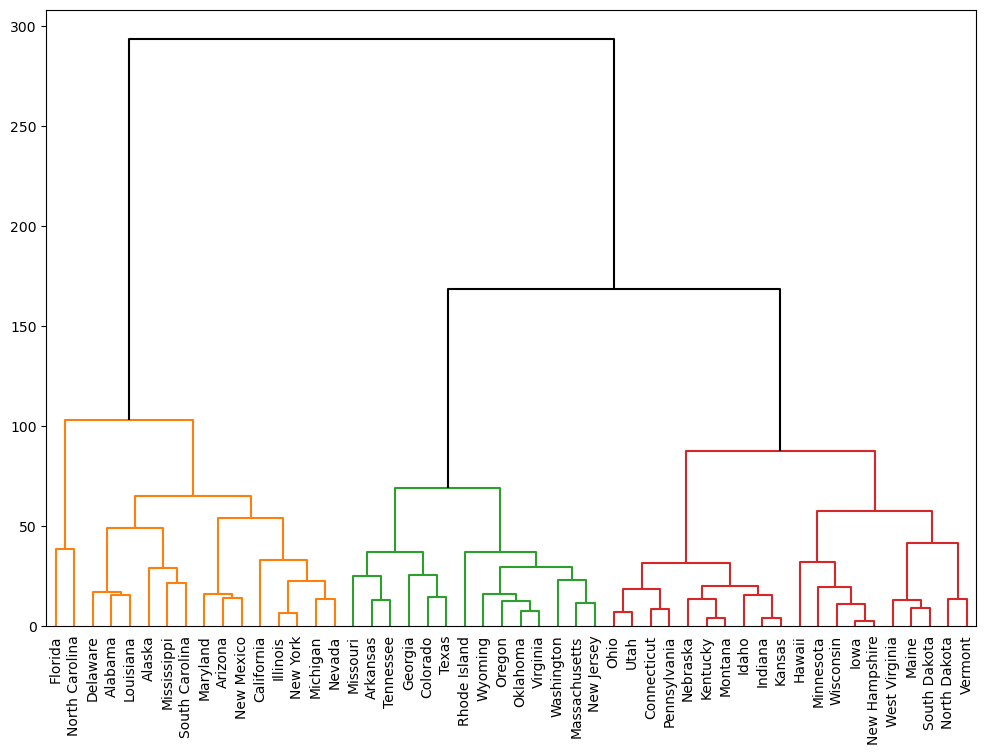

In [145]:
linkage = compute_linkage(HClust)
fig, ax = plt.subplots(1, 1, figsize = (12, 8))
dendrogram(linkage, labels = USArrests.index,
           ax = ax,
           color_threshold = 120, 
           above_threshold_color = 'black')
plt.xticks(fontsize = 10)
plt.show()

In [146]:
df1 = pd.DataFrame(cut_tree(linkage, n_clusters = 3))
#df.index.name = 'State'
df1['State'] = USArrests.index
df1.rename(columns = {0: 'Cluster'}, inplace = True)
df1

,Cluster,State
0,0,Alabama
1,0,Alaska
2,0,Arizona
3,1,Arkansas
4,0,California
5,1,Colorado
6,2,Connecticut
7,0,Delaware
8,0,Florida
9,1,Georgia


### Part c.

In [147]:
HClust = AgglomerativeClustering
h_comp = HClust(distance_threshold = 0,
               n_clusters = None,
               linkage = 'complete')
h_comp.fit(USArrestsScaled)

,n_clusters,None
,metric,'euclidean'
,memory,None
,connectivity,None
,compute_full_tree,'auto'
,linkage,'complete'
,distance_threshold,0
,compute_distances,False


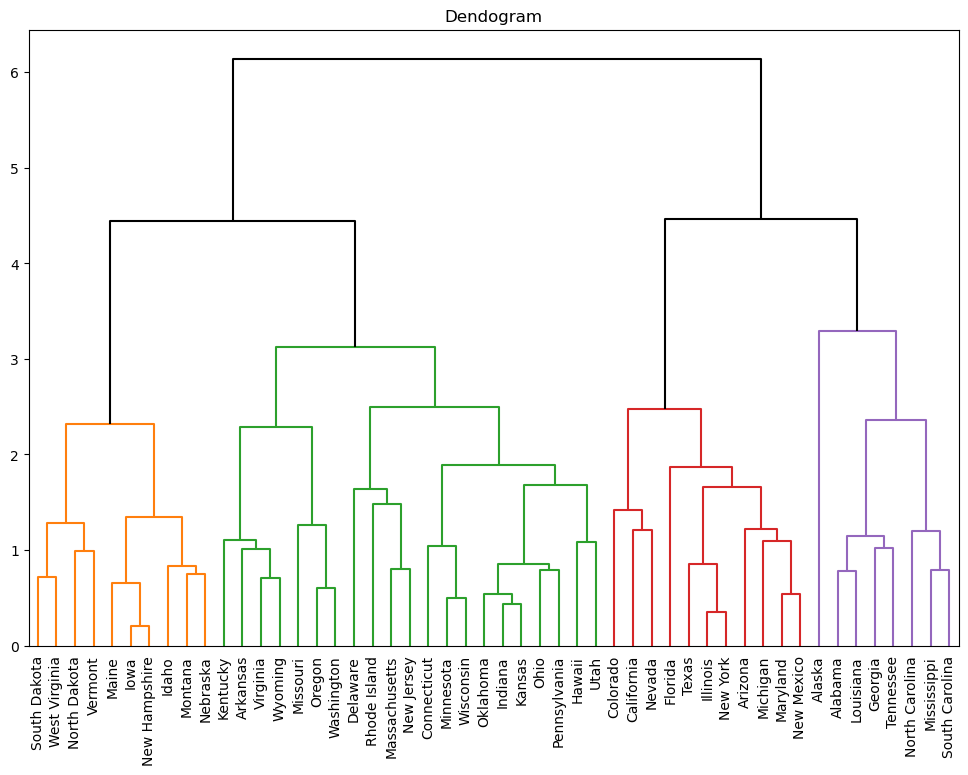

In [148]:
linkage = compute_linkage(h_comp)
fig, ax = plt.subplots(1, 1, figsize = (12, 8))
dendrogram(linkage, labels = USArrests.index,
           ax = ax,
           color_threshold = 4, 
           above_threshold_color = 'black')           
plt.xticks(fontsize = 10)
plt.title('Dendogram')
plt.show()

#### Note: leaf nodes are shown in descending order, from left to right (left = 3, right = 0).

In [149]:
df2 = pd.DataFrame(cut_tree(linkage, n_clusters = 4))
#df.index.name = 'State'
df2['State'] = USArrests.index
df2.rename(columns = {0: 'Cluster'}, inplace = True)
df2

,Cluster,State
0,0,Alabama
1,0,Alaska
2,1,Arizona
3,2,Arkansas
4,1,California
5,1,Colorado
6,2,Connecticut
7,2,Delaware
8,1,Florida
9,0,Georgia


### Part d.

In [150]:
df3 = df1.join(df2, lsuffix = ' un-scaled', rsuffix = ' scaled')
df3

,Cluster un-scaled,State un-scaled,Cluster scaled,State scaled
0,0,Alabama,0,Alabama
1,0,Alaska,0,Alaska
2,0,Arizona,1,Arizona
3,1,Arkansas,2,Arkansas
4,0,California,1,California
5,1,Colorado,1,Colorado
6,2,Connecticut,2,Connecticut
7,0,Delaware,2,Delaware
8,0,Florida,1,Florida
9,1,Georgia,0,Georgia


In [151]:
string = df3['Cluster un-scaled'][df3['Cluster un-scaled'] == 0].count()
print(string, 'unscaled on node 0')

16 unscaled on node 0


In [152]:
string = df3['Cluster scaled'][df3['Cluster scaled'] == 0].count()
print(string, 'scaled on node 0')

8 scaled on node 0


In [153]:
string = df3['Cluster un-scaled'][df3['Cluster un-scaled'] == 1].count()
print(string, 'unscaled on node 1')

14 unscaled on node 1


In [154]:
string = df3['Cluster scaled'][df3['Cluster scaled'] == 1].count()
print(string, 'scaled on node 1')

11 scaled on node 1


In [155]:
string = df3['Cluster un-scaled'][df3['Cluster un-scaled'] == 2].count()
print(string, 'unscaled on node 2')

20 unscaled on node 2


In [156]:
string = df3['Cluster scaled'][df3['Cluster scaled'] == 2].count()
print(string, 'scaled on node 2')

21 scaled on node 2


In [157]:
string = df3['Cluster un-scaled'][df3['Cluster un-scaled'] == 3].count()
print(string, 'unscaled on node 3')

0 unscaled on node 3


In [158]:
string = df3['Cluster scaled'][df3['Cluster scaled'] == 3].count()
print(string, 'scaled on node 3')

10 scaled on node 3


##### Scaling increases observations in the third cluster (node 2).  Variables should be scaled prior to hierarchical clustering in this case because the units are different for each of the variables.